# N-Queens Benchmark Analysis

This notebook analyzes the performance of different N-Queens solving algorithms (Backtracking, Las Vegas, Mixed) based on the CSV data generated by the `NQueensBenchmark` tool.

**Key Metrics:**
- **N**: Board Size
- **K**: Number of randomly pre-placed queens (for Mixed algorithm)
- **TimeMS**: Execution time in milliseconds
- **NodesVisited**: Search tree complexity

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import requests

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

## 1. Load Data
Attempts to load data from GitHub first, then local file, and finally asks for manual upload if in Colab.

In [3]:
CSV_FILE_PATH = 'n_queens_benchmark.csv'
GITHUB_CSV_URL = 'https://raw.githubusercontent.com/kritchawat/2110742-Evolutionary-Computation/main/analysis/n_queens_benchmark.csv'

df = None
data_loaded = False

# 1. Attempt download from GitHub
if GITHUB_CSV_URL and 'username/repository' not in GITHUB_CSV_URL:
    try:
        print(f'Attempting to download from {GITHUB_CSV_URL}...')
        response = requests.get(GITHUB_CSV_URL)
        if response.status_code == 200:
            df = pd.read_csv(io.StringIO(response.text))
            print(f'Successfully loaded {len(df)} rows from GitHub.')
            data_loaded = True
        else:
            print(f'Failed to download from GitHub. Status code: {response.status_code}')
    except Exception as e:
        print(f'Error downloading from GitHub: {e}')
else:
    print('GitHub URL not configured or valid. Skipping download.')

# 2. Check local file (Standard Jupyter/Local)
if not data_loaded:
    try:
        df = pd.read_csv(CSV_FILE_PATH)
        print(f'Successfully loaded {len(df)} rows from local file: {CSV_FILE_PATH}')
        data_loaded = True
    except FileNotFoundError:
        print(f'Local file {CSV_FILE_PATH} not found.')

# 3. Fallback to Manual Upload (Google Colab)
if not data_loaded:
    try:
        from google.colab import files
        print('Running in Colab. Please upload the CSV file manually...')
        uploaded = files.upload()
        
        if uploaded:
            filename = next(iter(uploaded))
            df = pd.read_csv(io.BytesIO(uploaded[filename]))
            print(f'Successfully loaded {len(df)} rows from uploaded file: {filename}.')
            data_loaded = True
    except ImportError:
        print('Not running in Google Colab. Manual upload not available via this method.')

if not data_loaded:
    print('ERROR: Could not load data from any source. Please check the file path or URL.')

Attempting to download from https://raw.githubusercontent.com/kritchawat/2110742-Evolutionary-Computation/main/analysis/n_queens_benchmark.csv...
Failed to download from GitHub. Status code: 404
Successfully loaded 289085 rows from local file: n_queens_benchmark.csv


## 2. General Scalability Analysis (Time vs N)
How does the execution time grow as the board size increases?
Note: For the 'Mixed' algorithm, this plot aggregates all values of K, showing the spread of performance.

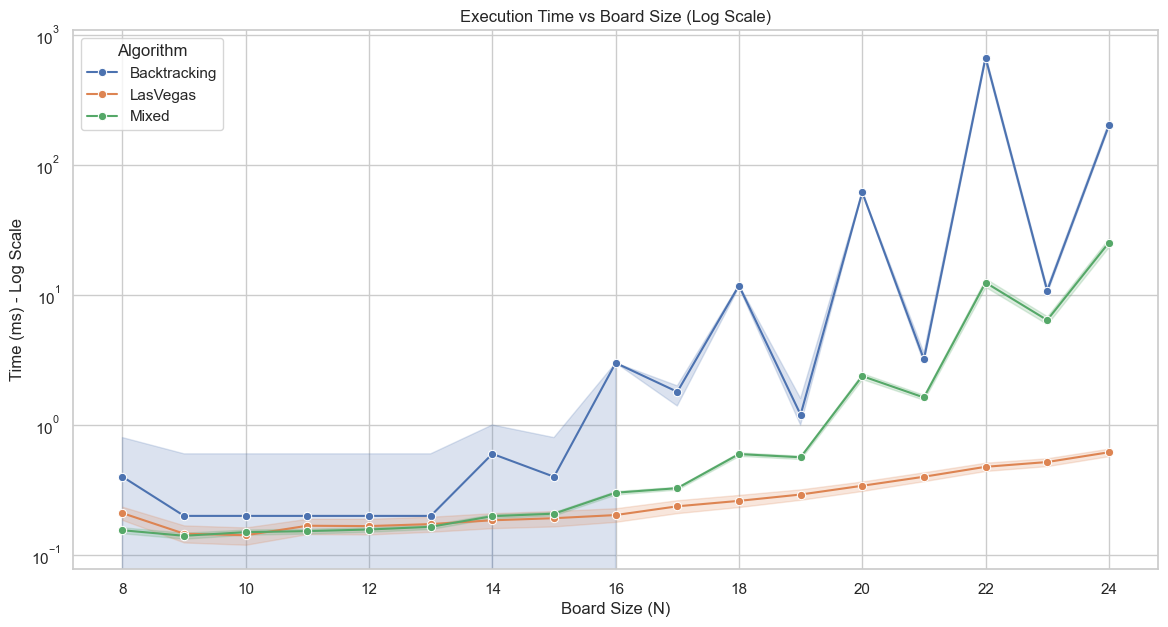

In [5]:
if 'df' in locals() and df is not None:
    plt.figure()
    # We use a lineplot with markers. 
    # Since Mixed has multiple Ks per N, the band shows the min-max range (confidence interval).
    sns.lineplot(data=df, x='N', y='TimeMS', hue='Algorithm', marker='o')
    
    plt.yscale('log')
    plt.title('Execution Time vs Board Size (Log Scale)')
    plt.ylabel('Time (ms) - Log Scale')
    plt.xlabel('Board Size (N)')
    plt.show()

## 3. Finding the Optimal 'K' for Mixed Algorithm
The Mixed algorithm places `K` queens randomly before switching to backtracking. 
This plot shows how changing `K` affects performance for specific large board sizes available in the dataset.

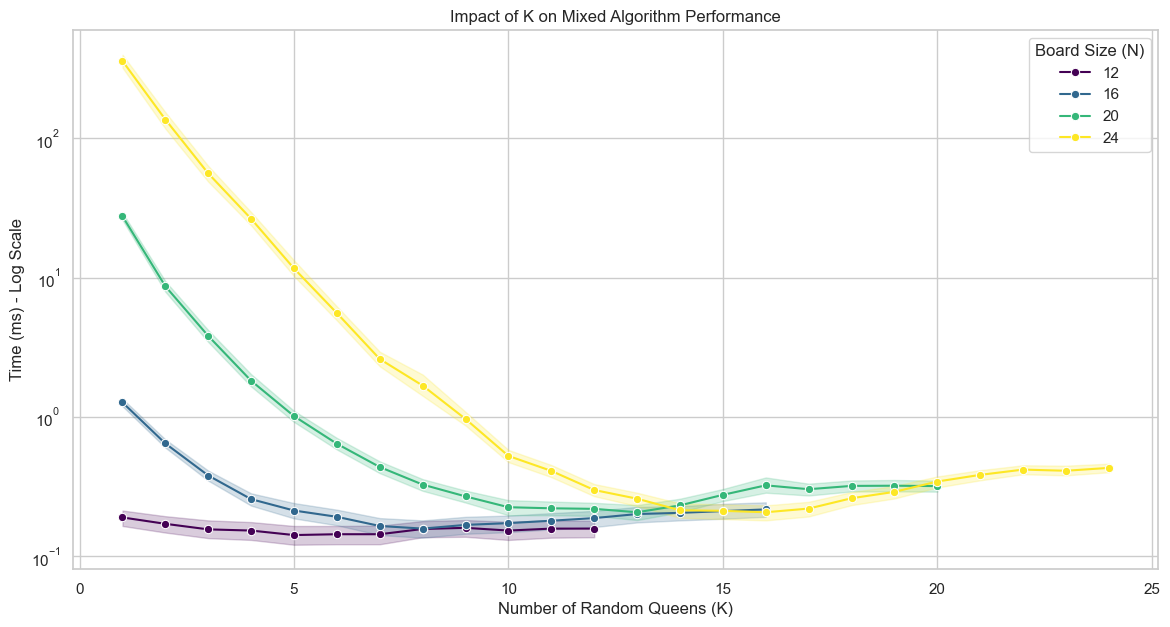

In [6]:
if 'df' in locals() and df is not None:
    # Filter for Mixed algorithm only
    mixed_df = df[df['Algorithm'] == 'Mixed']
    
    # Select representative large board sizes
    available_ns = sorted(mixed_df['N'].unique())
    # Pick 4 evenly spaced Ns from the upper half of the range if available
    if len(available_ns) > 4:
        step = max(1, len(available_ns) // 4)
        selected_ns = available_ns[::step][-4:]
    else:
        selected_ns = available_ns
    
    if len(selected_ns) > 0:
        subset = mixed_df[mixed_df['N'].isin(selected_ns)]
        
        plt.figure()
        sns.lineplot(data=subset, x='K', y='TimeMS', hue='N', palette='viridis', marker='o')
        
        plt.title('Impact of K on Mixed Algorithm Performance')
        plt.ylabel('Time (ms) - Log Scale')
        plt.xlabel('Number of Random Queens (K)')
        plt.yscale('log')
        plt.legend(title='Board Size (N)')
        plt.show()
    else:
        print('No data found for Mixed algorithm.')

## 4. Search Space Efficiency (Nodes Visited)
Comparing the raw number of steps taken by each algorithm.

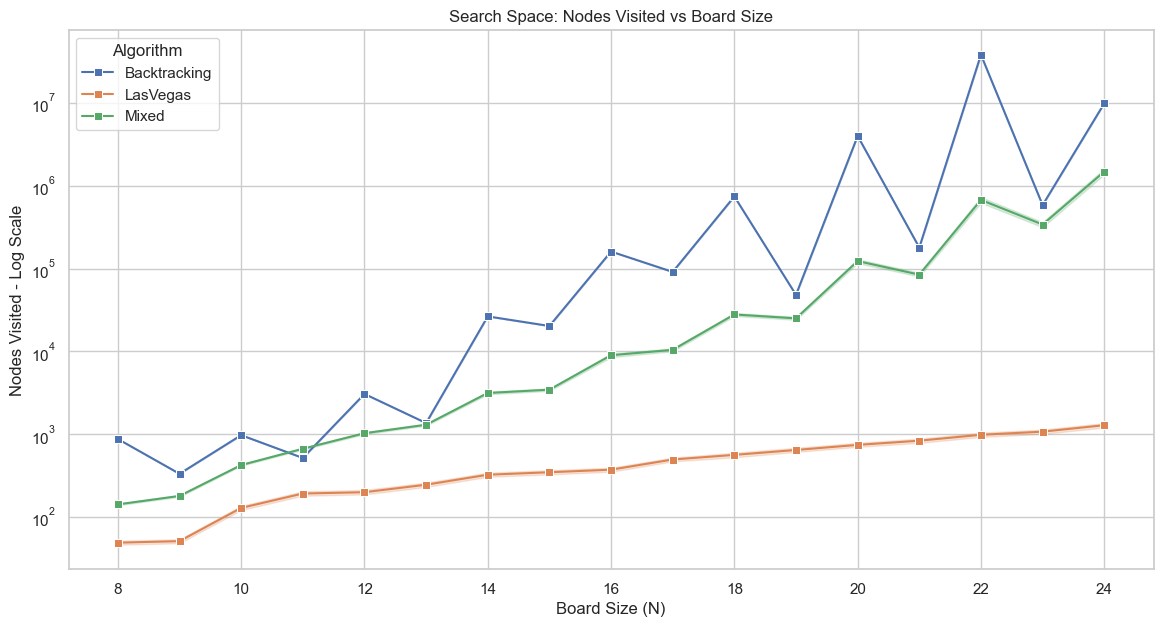

In [7]:
if 'df' in locals() and df is not None:
    plt.figure()
    sns.lineplot(data=df, x='N', y='NodesVisited', hue='Algorithm', marker='s')
    plt.yscale('log')
    plt.title('Search Space: Nodes Visited vs Board Size')
    plt.ylabel('Nodes Visited - Log Scale')
    plt.xlabel('Board Size (N)')
    plt.show()

## 5. Summary Statistics Table
Grouped by Algorithm, N, and K (for Mixed). Shows Mean Time and Success Rate.

In [8]:
if 'df' in locals() and df is not None:
    # Create a summary table
    summary = df.groupby(['Algorithm', 'N', 'K']).agg(
        Time_Mean=('TimeMS', 'mean'),
        Time_Std=('TimeMS', 'std'),
        Nodes_Mean=('NodesVisited', 'mean'),
        Success_Rate=('Success', 'mean'),
        Trials=('RunID', 'count')
    ).reset_index()
    
    # Sort by N descending to see largest boards first
    summary = summary.sort_values(by=['N', 'Algorithm'], ascending=[False, True])
    
    # Display the top rows
    display(summary.head(15))


,Algorithm,N,K,Time_Mean,Time_Std,Nodes_Mean,Success_Rate,Trials
16,Backtracking,24,0,201.000,12.389512,9.878316e+06,1.000,5
33,LasVegas,24,0,0.617,0.654782,1.285336e+03,1.000,1000
282,Mixed,24,1,359.076,587.161745,2.080879e+07,0.963,1000
283,Mixed,24,2,136.460,306.647330,8.394159e+06,0.990,1000
284,Mixed,24,3,55.966,120.402781,3.364450e+06,1.000,1000
285,Mixed,24,4,26.446,47.518218,1.567778e+06,1.000,1000
286,Mixed,24,5,11.637,23.961582,7.170609e+05,1.000,1000
287,Mixed,24,6,5.562,10.962771,3.422564e+05,1.000,1000
288,Mixed,24,7,2.604,5.158468,1.541048e+05,1.000,1000
289,Mixed,24,8,1.679,4.933589,9.397279e+04,1.000,1000
